In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [2]:
watch_data = pd.read_csv('unclean_smartwatch_health_data.csv')

In [3]:
watch_data

,User ID,Heart Rate (BPM),Blood Oxygen Level (%),Step Count,Sleep Duration (hours),Activity Level,Stress Level
0,4174.0,58.939776,98.809650,5450.390578,7.167235622316564,Highly Active,1
1,NaN,NaN,98.532195,727.601610,6.538239375570314,Highly_Active,5
2,1860.0,247.803052,97.052954,2826.521994,ERROR,Highly Active,5
3,2294.0,40.000000,96.894213,13797.338044,7.367789630207228,Actve,3
4,2130.0,61.950165,98.583797,15679.067648,NaN,Highly_Active,6
...,...,...,...,...,...,...,...
9995,1524.0,78.819386,98.931927,2948.491953,7.402748595032027,Active,7
9996,4879.0,48.632659,95.773035,4725.623070,6.3821659358529015,Sedentary,2
9997,2624.0,73.834442,97.945874,2571.492060,6.91654920303435,Sedentary,4
9998,4907.0,NaN,98.401058,3364.788855,5.691233932149209,Active,8


In [4]:
watch_data.isnull().sum()

User ID                   201
Heart Rate (BPM)          400
Blood Oxygen Level (%)    300
Step Count                100
Sleep Duration (hours)    150
Activity Level            200
Stress Level              200
dtype: int64

In [5]:
watch_data['User ID'].dropna(inplace= True)

In [6]:
watch_data['Sleep Duration (hours)'] = pd.to_numeric(watch_data['Sleep Duration (hours)'], errors='coerce')

In [7]:
watch_data['Stress Level'] = pd.to_numeric(watch_data['Stress Level'], errors='coerce')

In [8]:
watch_data

,User ID,Heart Rate (BPM),Blood Oxygen Level (%),Step Count,Sleep Duration (hours),Activity Level,Stress Level
0,4174.0,58.939776,98.809650,5450.390578,7.167236,Highly Active,1.0
1,NaN,NaN,98.532195,727.601610,6.538239,Highly_Active,5.0
2,1860.0,247.803052,97.052954,2826.521994,NaN,Highly Active,5.0
3,2294.0,40.000000,96.894213,13797.338044,7.367790,Actve,3.0
4,2130.0,61.950165,98.583797,15679.067648,NaN,Highly_Active,6.0
...,...,...,...,...,...,...,...
9995,1524.0,78.819386,98.931927,2948.491953,7.402749,Active,7.0
9996,4879.0,48.632659,95.773035,4725.623070,6.382166,Sedentary,2.0
9997,2624.0,73.834442,97.945874,2571.492060,6.916549,Sedentary,4.0
9998,4907.0,NaN,98.401058,3364.788855,5.691234,Active,8.0


In [9]:
watch_data['User ID'].mean()
watch_data['User ID'].fillna(3007.4,inplace= True)
watch_data['Heart Rate (BPM)'].mean()
watch_data['Heart Rate (BPM)'].fillna(76.035461,inplace= True)
watch_data['Blood Oxygen Level (%)'].mean()
watch_data['Blood Oxygen Level (%)'].fillna(97.84158,inplace = True)
watch_data['Step Count'].mean()
watch_data['Step Count'].fillna(6985.685884,inplace=True)
watch_data['Sleep Duration (hours)'].mean()
watch_data['Sleep Duration (hours)'].fillna(6.50546,inplace= True)
watch_data['Activity Level'].mode()
watch_data['Activity Level'].fillna('Sedentary',inplace=True)
watch_data['Stress Level'].mean()
watch_data['Stress Level'].fillna(5.5,inplace = True)

In [10]:
watch_data

,User ID,Heart Rate (BPM),Blood Oxygen Level (%),Step Count,Sleep Duration (hours),Activity Level,Stress Level
0,4174.0,58.939776,98.809650,5450.390578,7.167236,Highly Active,1.0
1,3007.4,76.035461,98.532195,727.601610,6.538239,Highly_Active,5.0
2,1860.0,247.803052,97.052954,2826.521994,6.505460,Highly Active,5.0
3,2294.0,40.000000,96.894213,13797.338044,7.367790,Actve,3.0
4,2130.0,61.950165,98.583797,15679.067648,6.505460,Highly_Active,6.0
...,...,...,...,...,...,...,...
9995,1524.0,78.819386,98.931927,2948.491953,7.402749,Active,7.0
9996,4879.0,48.632659,95.773035,4725.623070,6.382166,Sedentary,2.0
9997,2624.0,73.834442,97.945874,2571.492060,6.916549,Sedentary,4.0
9998,4907.0,76.035461,98.401058,3364.788855,5.691234,Active,8.0


In [21]:
def infer_sql_types(dtype):
    if pd.api.types.is_integer_dtype(dtype):
        return 'INT'
    elif pd.api.types.is_bool_dtype(dtype):
        return 'BOOLEAN'
    elif pd.api.types.is_float_dtype(dtype):
        return 'FLOAT'
    elif pd.api.types.is_datetime64_any_dtype(dtype):
        return 'TIMESTAMP'
    else:
        return 'TEXT'
table_name = 'unclean_smartwatch_health_data'
columns = watch_data.dtypes
sql_columns = ',\n '.join([f'"{col}"{infer_sql_types(dtype)}' for col, dtype in columns.items()])

create_stmt = f"""
CREATE TABLE IF NOT EXISTS {table_name} (
 {sql_columns}
);
"""

print(create_stmt)


CREATE TABLE IF NOT EXISTS unclean_smartwatch_health_data (
 "User ID"FLOAT,
 "Heart Rate (BPM)"FLOAT,
 "Blood Oxygen Level (%)"FLOAT,
 "Step Count"FLOAT,
 "Sleep Duration (hours)"TEXT,
 "Activity Level"TEXT,
 "Stress Level"TEXT
);



In [25]:
import psycopg2
conn = psycopg2.connect(
    dbname = "postgres",
    user="postgres",
    password="postgres",
    host="localhost",
    port="5432"
)

cur = conn.cursor()
# Create table manually here or auto-generate
cur.execute(create_stmt)
conn.commit()

# Auto-generate INSERT statement
columns = list(watch_data.columns)
placeholders = ', '.join(['%s'] * len(columns))
insert_stmt = f"""INSERT INTO {table_name} ({', '.join(['"{}"'.format(col) for col in columns])}) 
VALUES ({placeholders})
"""

# Insert data row by row
for _, row in watch_data.iterrows():
    cur.execute(insert_stmt, tuple(row))


conn.commit()
cur.close()
conn.close()


IndexError: tuple index out of range

In [11]:
watch_data.isnull().sum()

User ID                   0
Heart Rate (BPM)          0
Blood Oxygen Level (%)    0
Step Count                0
Sleep Duration (hours)    0
Activity Level            0
Stress Level              0
dtype: int64

In [12]:
watch_data['Activity Level'].value_counts()

Activity Level
Sedentary        1857
Seddentary       1676
Highly Active    1650
Active           1643
Actve            1622
Highly_Active    1552
Name: count, dtype: int64

In [31]:
class watch_analysis:
    watch_data = pd.read_csv('unclean_smartwatch_health_data.csv')
    def __init__(self,watch_data):
        watch_data = self.watch_data
    def avg_heartrate(self):
        return watch_data['Heart Rate (BPM)'].mean()
    def highest_heartrate(self):
        return watch_data.sort_values(by = 'Heart Rate (BPM)',ascending = False).head(5)[['Heart Rate (BPM)','User ID','Activity Level','Step Count']]
    def max_stepcount_activity_level(self):
        return watch_data.sort_values(by='Step Count',ascending = False).head(1)['Activity Level']
    def stress_level(self):
        return watch_data.groupby('Activity Level')['Stress Level'].mean()
    def bar_graph(self):
        activity_cnt = watch_data['Activity Level'].value_counts()
        plt.figure(figsize = (10,5))
        return sns.barplot(x=activity_cnt.index,y=activity_cnt.values)
    def get_outliers(self,col):
        q1 = watch_data[col].describe()['25%']
        q3 = watch_data[col].describe()['75%']
        iqr = q3-q1
        return [val for val in watch_data['Sleep Duration (hours)'].values if val >q3 + (1.5*iqr)],\
               [val for val in watch_data['Sleep Duration (hours)'].values if val<q1-(1.5*iqr)]

Average heartrate:
76.03546172620175
Highest heart rate activity:
      Heart Rate (BPM)  User ID Activity Level    Step Count
4185        296.593970   4643.0      Sedentary  54698.646371
9438        293.221756   4411.0  Highly Active  11209.020829
3113        292.923300   1035.0         Active   5303.010562
8471        291.403077   2706.0          Actve  19209.243829
8369        288.257761   2283.0  Highly_Active  21495.639335
max_stepcount_activity_level:
4018    Sedentary
Name: Activity Level, dtype: object
stress_level:
Activity Level
Active           5.517042
Actve            5.366215
Highly Active    5.440909
Highly_Active    5.509987
Seddentary       5.496420
Sedentary        5.460420
Name: Stress Level, dtype: float64
barplot:
Axes(0.125,0.11;0.775x0.77)
outliers:
([11.007690206138836, 10.49906566073934, 10.645764905139025, 12.140232872862926, 10.39685873160814, 10.474965653500968, 10.455505451370964, 10.771841135205712, 10.702359920096209, 10.53120691953875, 10.596063308526192

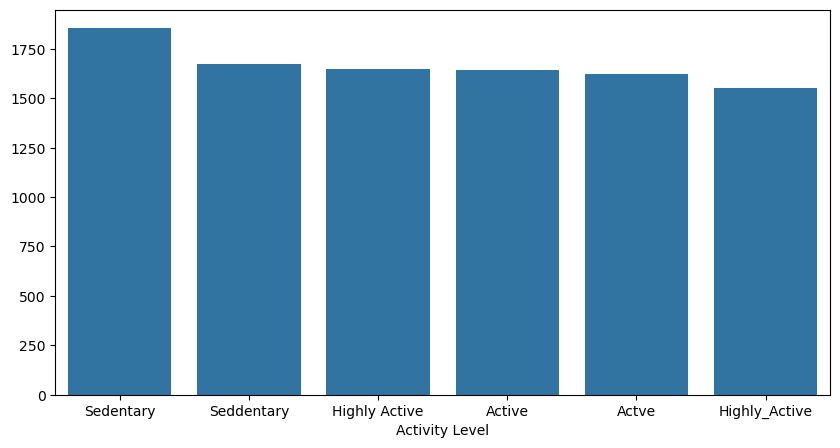

In [32]:
obj_balu = watch_analysis(watch_data)
print('Average heartrate:')
print(obj_balu.avg_heartrate())

print('Highest heart rate activity:')
print(obj_balu.highest_heartrate())

print('max_stepcount_activity_level:')
print(obj_balu.max_stepcount_activity_level())

print('stress_level:')
print(obj_balu.stress_level())

print('barplot:')
print(obj_balu.bar_graph())

print('outliers:')
print(obj_balu.get_outliers('Sleep Duration (hours)'))


In [4]:
con_cols = watch_data.select_dtypes(include=['int64', 'float64']).columns.tolist()
con_cols

['User ID', 'Heart Rate (BPM)', 'Blood Oxygen Level (%)', 'Step Count']

In [6]:
def get_outliers(col):
    q1 = watch_data[col].describe()['25%']
    q3 = watch_data[col].describe()['75%']
    iqr = q3-q1
    return [val for val in watch_data['Heart Rate (BPM)'].values if val >q3 + (1.5*iqr)],\
           [val for val in watch_data['Heart Rate (BPM)'].values if val<q1-(1.5*iqr)]

get_outliers('Heart Rate (BPM)')

([247.8030522923432,
  118.29493321826284,
  200.49164217071984,
  219.1991782129313,
  232.9449069272243,
  264.46735633766275,
  226.2567250935164,
  265.5429095106564,
  117.71060779267508,
  207.1021876945045,
  130.3120020224745,
  207.43024338048195,
  117.15926886369355,
  215.19468105471688,
  204.0678112444548,
  209.77392353062743,
  228.4980779780263,
  256.377377355097,
  283.58578538080286,
  121.7452204952703,
  116.86122514348094,
  292.9232995560192,
  282.8631240383314,
  127.58807105317372,
  243.8769779618632,
  284.05525490682896,
  118.36817774758477,
  271.4957856042119,
  231.25544172033543,
  125.73364314352746,
  276.12398317377074,
  296.5939695131042,
  123.25475380185284,
  204.0576099318878,
  249.617291391865,
  269.1459746695917,
  250.62067876216804,
  246.0941444842628,
  115.73846179568152,
  118.5325595220546,
  264.64281151638994,
  231.0362871673195,
  234.8409357359941,
  122.10106676240682,
  274.2969041634161,
  257.82968587553705,
  263.37578972

In [7]:
# STATISTICAL ANALYSIS
# CORRELATION
from scipy.stats import f_oneway

In [8]:
con_cols = watch_data.select_dtypes(include=['int64', 'float64']).columns.tolist()
con_cols

['User ID', 'Heart Rate (BPM)', 'Blood Oxygen Level (%)', 'Step Count']

In [9]:
cat_cols = [col for col in watch_data.columns if watch_data[col].dtypes == 'object']
cat_cols

['Sleep Duration (hours)', 'Activity Level', 'Stress Level']

In [20]:
#used PCC method for both continous variables
for i in range(len(continuous_var)):
    for j in range(i+1, len(continuous_var)):
        first = continuous_var[i]
        second = continuous_var[j]
        value = np.corrcoef(watch_data[first], watch_data[second])[0][1]
        print(f"{first} vs {second} => Correlation: {round(value, 3)}")

User ID vs Heart Rate (BPM) => Correlation: nan
User ID vs Blood Oxygen Level (%) => Correlation: nan
User ID vs Step Count => Correlation: nan
Heart Rate (BPM) vs Blood Oxygen Level (%) => Correlation: nan
Heart Rate (BPM) vs Step Count => Correlation: nan
Blood Oxygen Level (%) vs Step Count => Correlation: nan


In [16]:
corrs = watch_data[continuous_var + ['Heart Rate (BPM)']].corr()['Heart Rate (BPM)'].drop('Heart Rate (BPM)')
strong_corrs = corrs[abs(corrs) > 0.05]
print(strong_corrs)

                        Heart Rate (BPM)  Heart Rate (BPM)
User ID                              NaN               NaN
Blood Oxygen Level (%)               NaN               NaN
Step Count                           NaN               NaN


<Axes: >

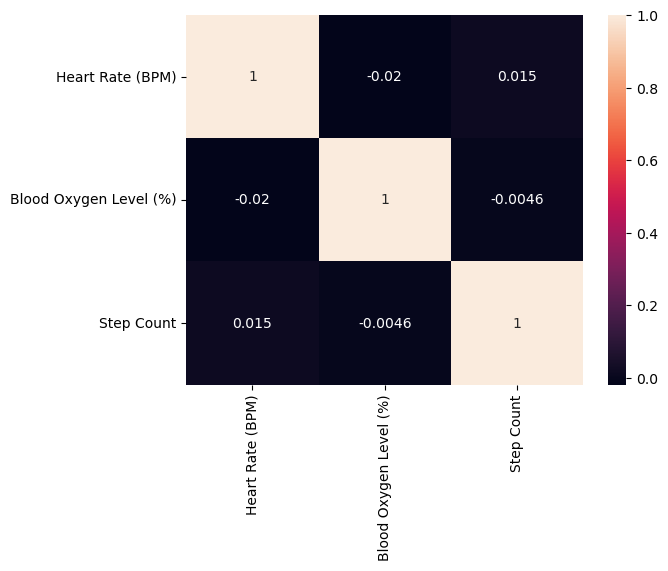

In [18]:
sns.heatmap(watch_data[[ 'Heart Rate (BPM)', 'Blood Oxygen Level (%)', 'Step Count']].corr(),annot = True)